# Medidas de heterogeneidad

**Almacenes y Minería de Datos · Práctica 4**

Este notebook calcula tres índices de heterogeneidad sobre variables cualitativas del conjunto ENDIREH 2021 ya preprocesado y explica cómo leerlos. Los índices provienen de `src/visualization/indices.py`, las tablas de frecuencias de `src/visualization/eda.py` y la figura de `src/visualization/graficas.py`; aquí solo se presentan los resultados y su interpretación.

## 1. Qué son las medidas de heterogeneidad

Las medidas de heterogeneidad se aplican a variables cualitativas. Indican qué tan repartidos están los casos entre las categorías: si casi todos caen en una sola, la variable es homogénea; si se reparten de forma pareja, es heterogénea.

Sea $k$ el número de categorías y $p_i$ la proporción de casos en la categoría $i$.

| Índice | Fórmula | Va de | Cómo se lee |
|---|---|---|---|
| Gini-Simpson | $GS = 1 - \sum_{i=1}^{k} p_i^2$ | 0 a $\frac{k-1}{k}$ | La probabilidad de que dos casos tomados al azar pertenezcan a categorías distintas |
| Índice de variación cualitativa (IQV) | $IQV = \frac{k\left(1 - \sum_{i=1}^{k} p_i^2\right)}{k-1}$ | 0 a 1 | El Gini-Simpson expresado como fracción de su máximo |
| Entropía de Shannon | $H = -\sum_{i=1}^{k} p_i \log_2 p_i$ | 0 a $\log_2 k$ | La incertidumbre, medida en bits, sobre la categoría de un caso tomado al azar |

Los tres valen 0 cuando una sola categoría reúne todos los casos y alcanzan su máximo cuando las $k$ categorías tienen la misma proporción. La diferencia está en ese máximo. El del Gini-Simpson y el de la entropía crecen con el número de categorías, por lo que sus valores no se pueden comparar entre variables con distinto $k$. El IQV divide entre el máximo y siempre va de 0 a 1. La entropía normalizada, $H / \log_2 k$, cumple el mismo papel para la entropía y también se incluye en la tabla de la sección 3.2.

### Ponderación

Las proporciones $p_i$ se calculan sobre la población estimada: la proporción de una categoría es la suma del factor de expansión de sus registros entre la suma de todos. Así los índices describen cómo se reparten las mujeres del país y no solo las encuestadas. La sección 3.4 muestra el efecto de esta decisión.

### Variables

Se miden cuatro variables de significado conocido y sin valores faltantes: el estado conyugal (`estado_civil_desc`), el estrato socioeconómico (`estrato_socioeconomico`), la entidad federativa (`nom_entidad`) y la variable que indica si la encuestada reportó violencia de pareja (`sufrio_violencia_pareja`, donde 1 significa que la reportó). La variable `nivel_escolaridad` queda fuera porque sus categorías, de A1 a C2, no corresponden a un catálogo que permita interpretarlas.

## 2. Datos

Se parte del archivo que produce `src/cleaning/limpieza.py`. Las cuatro variables tienen valor en todos los registros.

In [1]:
import sys
from pathlib import Path

import polars as pl
from IPython.display import Image, display

# La raíz del proyecto entra al path para importar config/ y src/.
RAIZ = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
sys.path.append(str(RAIZ))

from config.rutas import RUTA_ENDIREH_LIMPIO, RUTA_FIGURAS
from src.visualization.eda import seccion_cualitativas
from src.visualization.graficas import figura_08_heterogeneidad
from src.visualization.indices import (
    VARIABLES_HETEROGENEIDAD,
    comprobar,
    seccion_heterogeneidad,
)

df = pl.read_parquet(RUTA_ENDIREH_LIMPIO)

print(f"Registros: {df.height:,}")
print(f"Población representada: {df['factor_expansion'].sum():,.0f} mujeres de 15 años y más")

Registros: 105,752
Población representada: 49,144,897 mujeres de 15 años y más


## 3. Resultados

### 3.1 Distribución de las categorías

Los índices parten de las proporciones de cada categoría, que se muestran primero. La columna de población es la que entra al cálculo.

In [2]:
seccion_cualitativas(df, VARIABLES_HETEROGENEIDAD)


 VARIABLES CUALITATIVAS (moda y frecuencias)

En una variable cualitativa la única medida de tendencia central
válida es la moda. En una ordinal además tiene sentido la mediana,
pero nunca la media.

--- estado_civil_desc   (moda ponderada: Casada)
    Categoría                              Frec.   % muestra   % población
    ----------------------------------------------------------------------
    Casada                                42,201       39.9%         35.0%
    Soltera                               19,798       18.7%         26.1%
    Unión libre                           22,208       21.0%         18.4%
    Viuda                                  9,746        9.2%          8.9%
    Separada                               8,626        8.2%          8.8%
    Divorciada                             3,173        3.0%          2.7%

--- estrato_socioeconomico   (moda ponderada: 2)
    Categoría                              Frec.   % muestra   % población
    ---------------------

**Interpretación.** Las cuatro variables se reparten de forma distinta. En el estado conyugal ninguna categoría alcanza la mitad de la población: las casadas son el 35.0 %, las solteras el 26.1 % y las mujeres en unión libre el 18.4 %. En el estrato socioeconómico una sola categoría, el estrato 2, reúne al 50.9 %. En la entidad federativa la población se distribuye entre 32 categorías, con el Estado de México como la mayor, con 14.0 %. En la variable de violencia de pareja el 82.2 % de la población no la reportó y el 17.8 % sí.

### 3.2 Índices de heterogeneidad

In [3]:
seccion_heterogeneidad(df)


 MEDIDAS DE HETEROGENEIDAD (población estimada)

    Variable                    k   Gini-Simpson      IQV   Entropía   Máxima   Normalizada
    ---------------------------------------------------------------------------------------
    estado_civil_desc           6         0.7588   0.9105     2.2468   2.5850        0.8692
    estrato_socioeconomico      4         0.6530   0.8706     1.7415   2.0000        0.8707
    nom_entidad                32         0.9458   0.9763     4.5909   5.0000        0.9182
    sufrio_violencia_pareja     2         0.2932   0.5865     0.6767   1.0000        0.6767


**Interpretación.** El IQV ordena las variables de más a menos heterogénea: entidad federativa (0.9763), estado conyugal (0.9105), estrato socioeconómico (0.8706) y violencia de pareja reportada (0.5865). El orden corresponde a lo que mostraban las frecuencias: en estas cuatro variables, cuanto más pesa la categoría mayor, menor es el índice.

La entidad federativa está cerca del máximo. Su entropía es de 4.5909 bits de 5 posibles, lo que indica que la población se reparte entre las 32 entidades de forma amplia, aunque no pareja. El estado conyugal también es muy heterogéneo, con 2.2468 bits de 2.5850. El estrato queda algo por debajo porque la mitad de la población pertenece a una sola categoría.

La variable de violencia reportada es la menos heterogénea, con 0.6767 bits de 1 posible. Ese valor refleja que una categoría predomina y no significa que el problema sea menor: el 17.8 % corresponde a las mujeres que reportaron violencia de pareja en la encuesta, y el índice solo describe cómo se reparte la población entre las dos respuestas.

El Gini-Simpson y la entropía sin normalizar no sirven para comparar estas variables entre sí. La entidad federativa tiene los valores más altos en ambos (0.9458 y 4.5909) en buena parte porque tiene 32 categorías. La comparación entre variables se hace con el IQV o con la entropía normalizada.

Las dos versiones normalizadas no siempre ordenan igual. Según el IQV, el estado conyugal es más heterogéneo que el estrato (0.9105 frente a 0.8706); según la entropía normalizada quedan prácticamente empatados (0.8692 y 0.8707). Cada índice da un peso distinto a las categorías pequeñas, por lo que una diferencia de milésimas entre dos variables no indica una diferencia real de heterogeneidad.

### 3.3 Comparación con el IQV

La figura compara las cuatro variables con el IQV, que es el índice adecuado cuando el número de categorías difiere.

[graficas] reports/figuras/08_heterogeneidad_iqv.png


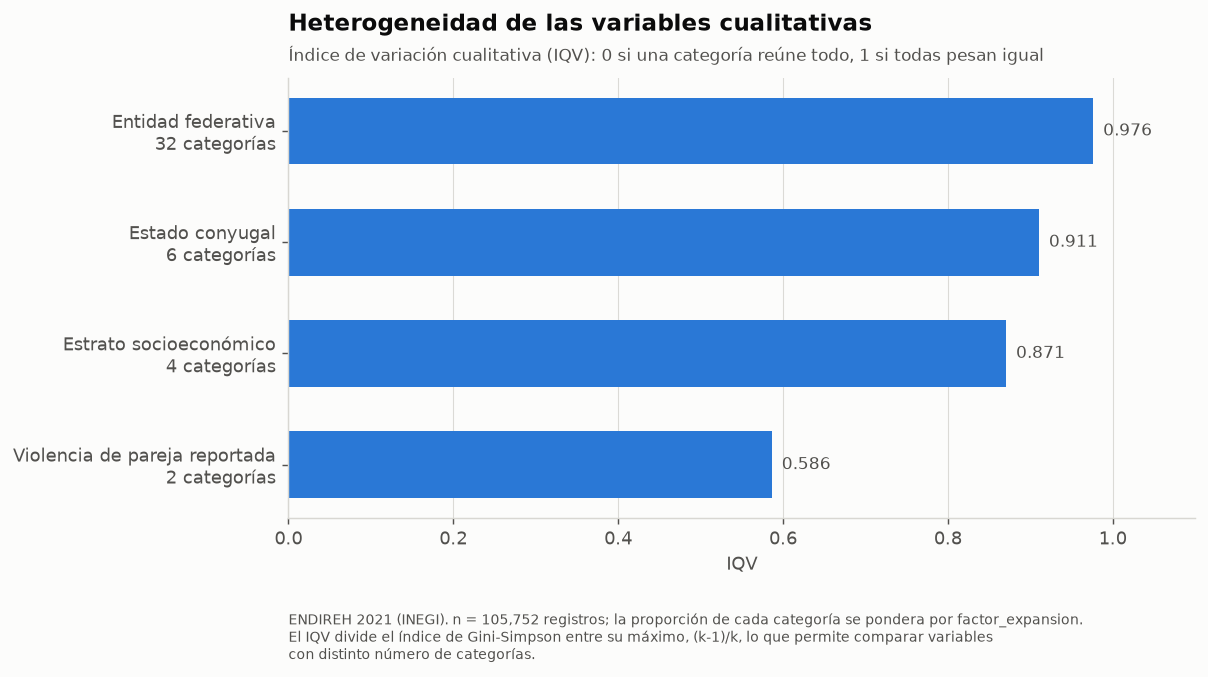

In [4]:
figura_08_heterogeneidad(df)
display(Image(filename=str(RUTA_FIGURAS / "08_heterogeneidad_iqv.png")))

**Interpretación.** Tres variables quedan por encima de 0.87 y cerca del máximo: en ellas la población está repartida entre varias categorías sin que una concentre a la gran mayoría. La violencia de pareja reportada se separa del resto porque una de sus dos categorías reúne al 82.2 % de la población.

### 3.4 Efecto de la ponderación

Los mismos índices, calculados sobre la muestra sin ponderar, muestran por qué se eligió la versión ponderada.

In [5]:
seccion_heterogeneidad(df, ponderada=False)


 MEDIDAS DE HETEROGENEIDAD (muestra sin ponderar)

    Variable                    k   Gini-Simpson      IQV   Entropía   Máxima   Normalizada
    ---------------------------------------------------------------------------------------
    estado_civil_desc           6         0.7456   0.8947     2.2180   2.5850        0.8580
    estrato_socioeconomico      4         0.6424   0.8565     1.7136   2.0000        0.8568
    nom_entidad                32         0.9687   1.0000     4.9989   5.0000        0.9998
    sufrio_violencia_pareja     2         0.2972   0.5944     0.6835   1.0000        0.6835


**Interpretación.** En la muestra, la entidad federativa alcanza un IQV de 1.0000 y una entropía de 4.9989 bits de 5 posibles, es decir, un reparto casi perfecto. Ese resultado es una propiedad del diseño de la encuesta y no del país: la tabla de la sección 3.1 muestra que se entrevistó a un número parecido de mujeres en cada entidad, alrededor del 3 % de la muestra, aunque su población es muy distinta. Al ponderar, el IQV baja a 0.9763 y la entropía a 4.5909.

En las otras tres variables el cambio es menor, de menos de tres centésimas en cualquiera de los índices. Aun así, los índices se calculan ponderados en las cuatro, para que describan a la población y sean comparables entre sí.

### 3.5 Comprobación de las funciones

Las funciones de los índices son propias del proyecto. El módulo las comprueba contra casos cuyo valor se conoce de antemano y contrasta la entropía con `scipy.stats.entropy` sobre las cuatro variables.

In [6]:
comprobar()

[indices] Casos de valor conocido
    Una categoría con todo, Gini-Simpson                  0.000000
    Una categoría con todo, IQV                           0.000000
    Una categoría con todo, entropía                      0.000000
    Cuatro categorías iguales, Gini-Simpson               0.750000
    Cuatro categorías iguales, IQV                        1.000000
    Cuatro categorías iguales, entropía                   2.000000
    Cuatro categorías iguales, entropía normalizada       1.000000
    Seis valores iguales, Gini                            0.000000
    Valores 1, 2, 3 y 4, Gini                             0.250000
    Valores 1, 2, 3 y 4, Gini por área de Lorenz          0.250000
    Todo en una de 6 unidades, Gini                       0.833333
    Todo en una de 32 unidades, Gini                      0.968750

[indices] Entropía ponderada contra scipy.stats.entropy
    estado_civil_desc                                     2.246821
    estrato_socioeconomico            

Los casos de valor conocido confirman los extremos descritos en la sección 1: una categoría que reúne todo da 0 en los tres índices y cuatro categorías iguales dan el máximo de cada uno. La entropía propia coincide con la de SciPy en las cuatro variables. Los casos del coeficiente de Gini corresponden al notebook de medidas de concentración.

## 4. Conclusión

La entropía y el IQV ponderados de las cuatro variables son los siguientes: entidad federativa, 4.5909 bits e IQV de 0.9763; estado conyugal, 2.2468 bits e IQV de 0.9105; estrato socioeconómico, 1.7415 bits e IQV de 0.8706; violencia de pareja reportada, 0.6767 bits e IQV de 0.5865.

La población se reparte de forma amplia entre entidades, estados conyugales y estratos, mientras que en la variable de violencia predomina la categoría que no la reportó. Una heterogeneidad baja en esa variable describe la proporción entre las dos respuestas y no reduce la importancia del 17.8 % que sí reportó violencia.